# Recommendation systems

In [27]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

## Carga de datos

In [28]:
with open('../../data/processed/recommendation-X-train.pkl', 'rb') as file:
    X_train = pickle.load(file)

with open('../../data/processed/recommendation-X-test.pkl', 'rb') as file:
    X_test = pickle.load(file)

with open('../../data/processed/recommendation-y-train.pkl', 'rb') as file:
    y_train = pickle.load(file)

with open('../../data/processed/recommendation-y-test.pkl', 'rb') as file:
    y_test = pickle.load(file)

## Modelado Predictivo

In [29]:
model = RandomForestClassifier(random_state = 25, class_weight='balanced')
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:

y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 1, 1], shape=(6033,))

In [31]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8443560417702636

In [32]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      4529
           1       0.70      0.65      0.67      1504

    accuracy                           0.84      6033
   macro avg       0.80      0.78      0.79      6033
weighted avg       0.84      0.84      0.84      6033



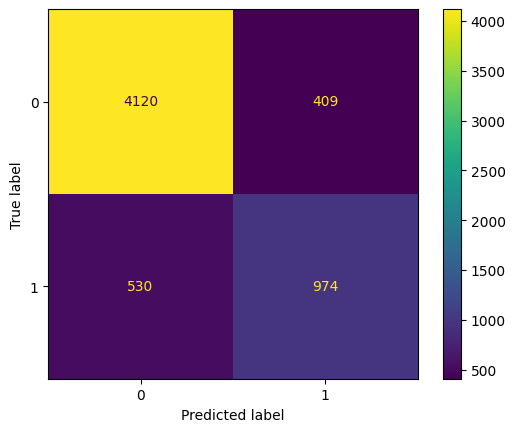

In [33]:
confusion = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion).plot()
plt.show()

>El modelo parece mostrar un accuracy de superior al 0.84, lo que es considerablemente alto, con el classification_report y la matriz de confusión podemos ver también que predice mejor los resultados de menos de 50K que los de más, aunque tenga una buena predicción en general.

## Optimización del modelo

In [34]:
hyperparams = {
    "n_estimators": [100, 200, 300],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

In [35]:
grid = RandomizedSearchCV(model, hyperparams, scoring = "accuracy", cv = 10)
grid

,estimator,RandomForestC...ndom_state=25)
,param_distributions,"{'class_weight': [None, 'balanced', ...], 'criterion': ['gini', 'entropy', ...], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [36]:
grid.fit(X_train, y_train)
grid.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': None,
 'max_depth': None,
 'criterion': 'log_loss',
 'class_weight': None}

In [37]:
best = grid.best_estimator_
y_pred_best = best.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
accuracy, accuracy_best 

(0.8443560417702636, 0.8506547323056523)

In [38]:
grid_report = classification_report(y_test, y_pred_best)
print(report, grid_report)

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      4529
           1       0.70      0.65      0.67      1504

    accuracy                           0.84      6033
   macro avg       0.80      0.78      0.79      6033
weighted avg       0.84      0.84      0.84      6033
               precision    recall  f1-score   support

           0       0.88      0.92      0.90      4529
           1       0.73      0.64      0.68      1504

    accuracy                           0.85      6033
   macro avg       0.81      0.78      0.79      6033
weighted avg       0.85      0.85      0.85      6033



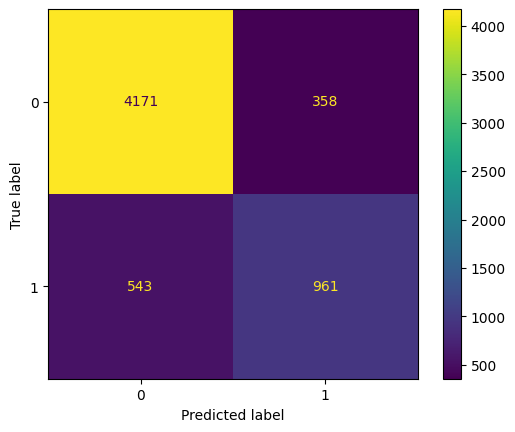

In [39]:
confusion_best = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(confusion_best).plot()
plt.show()

>En la optimización del modelo vemos que hay una mejora leve en el accuracy general, pero vemos también que esta mejora se centra en los casos donde la gente ingresa menos de 50K empeorando en la precisión de la decisión de más de 50K en ingresos, pasamos de un accuracy 0.844 a 0.850 (valores truncados), que es una mejora muy leve pero suficiente como para quedarnos con el modelo mejorado.

## Definición del segundo problema

>Tenemos que predecir que categorías de las que tenemos en el dataframe se podrían mejorar para pasar de ingresar menos de 50K o más.

## Sistema de recomendación


Categorías variables -> workclass, education-num, occupation, hours.per.week